<a href="https://colab.research.google.com/github/fauziah-azzhr/PertemuanTigaBelas/blob/main/Pertemuan13LatihanPraktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LATIHAN 1: KNN UNTUK DIGIT RECOGNITION
Dataset Shape: (1797, 64)
Number of Classes: 10


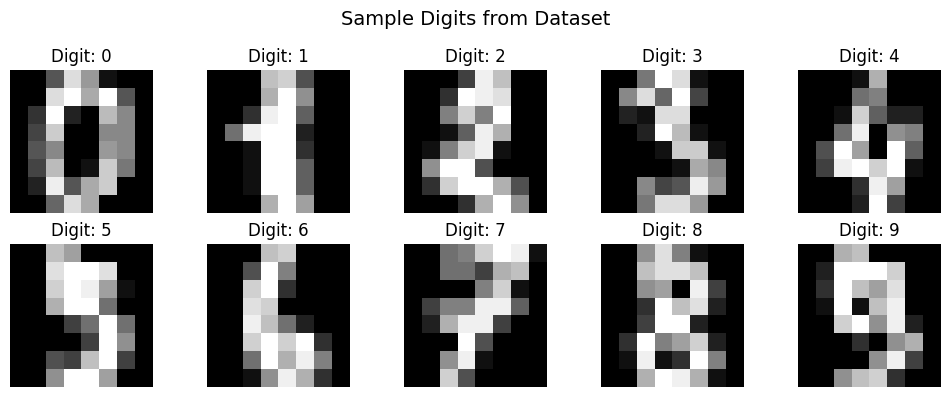

k=1: CV Accuracy=0.9865, Test Accuracy=0.9870
k=3: CV Accuracy=0.9849, Test Accuracy=0.9870
k=5: CV Accuracy=0.9825, Test Accuracy=0.9870
k=7: CV Accuracy=0.9801, Test Accuracy=0.9833
k=9: CV Accuracy=0.9769, Test Accuracy=0.9778
k=11: CV Accuracy=0.9729, Test Accuracy=0.9796


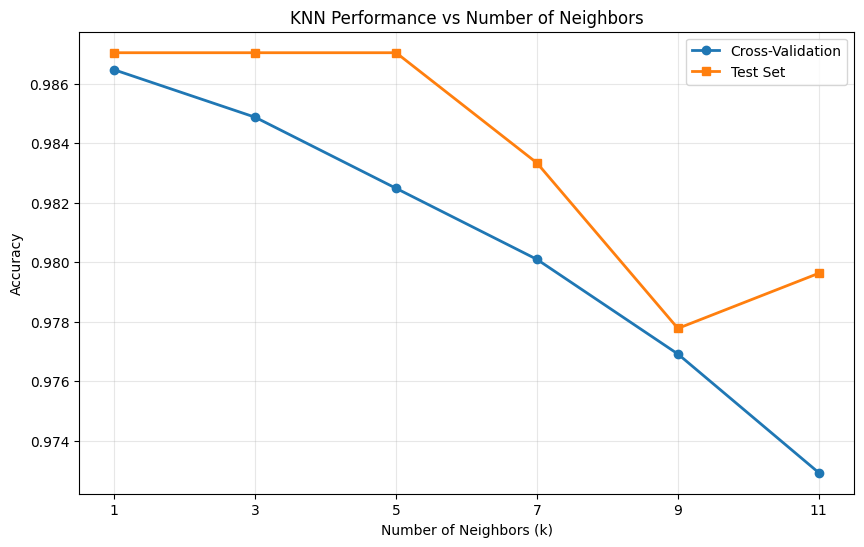


Best k value: 1


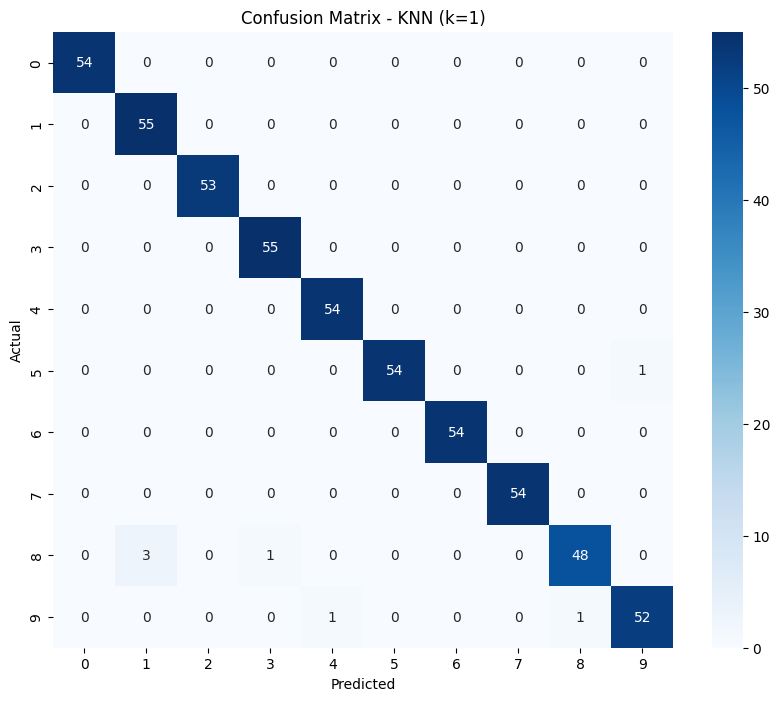


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.95      1.00      0.97        55
           2       1.00      1.00      1.00        53
           3       0.98      1.00      0.99        55
           4       0.98      1.00      0.99        54
           5       1.00      0.98      0.99        55
           6       1.00      1.00      1.00        54
           7       1.00      1.00      1.00        54
           8       0.98      0.92      0.95        52
           9       0.98      0.96      0.97        54

    accuracy                           0.99       540
   macro avg       0.99      0.99      0.99       540
weighted avg       0.99      0.99      0.99       540


Number of misclassifications: 7/540 (1.30%)

Sample Misclassifications:


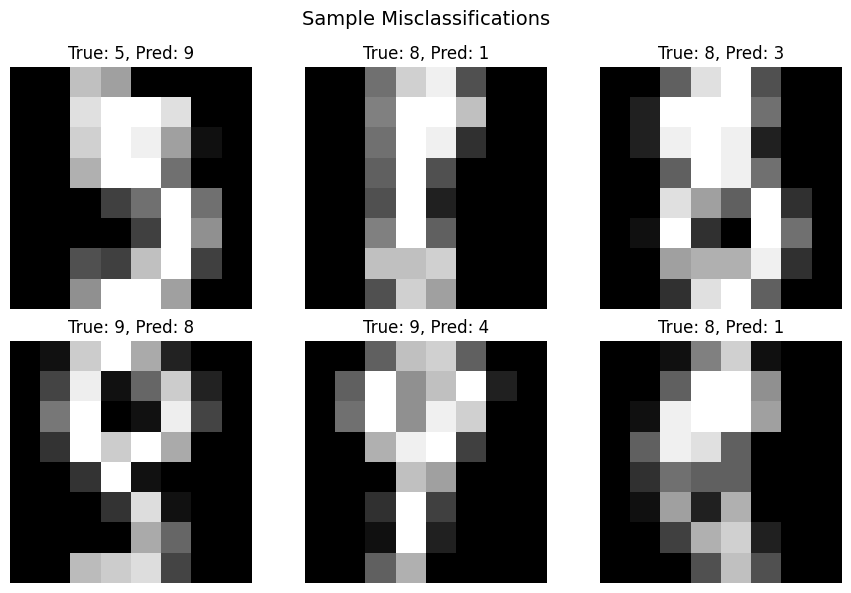

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Latihan 1: KNN untuk Digit Recognition
def praktikum_knn_digit():
    print("LATIHAN 1: KNN UNTUK DIGIT RECOGNITION")
    print("=" * 50)

    # Load dataset digit MNIST
    digits = load_digits()
    X = digits.data
    y = digits.target

    print(f"Dataset Shape: {X.shape}")
    print(f"Number of Classes: {len(np.unique(y))}")

    # Visualize sample digits
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(X[i].reshape(8, 8), cmap='gray')
        ax.set_title(f"Digit: {y[i]}")
        ax.axis('off')
    plt.suptitle("Sample Digits from Dataset", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Experiment with different k values
    k_values = [1, 3, 5, 7, 9, 11]
    cv_scores = []
    test_scores = []

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)

        # Cross-validation score
        cv_score = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
        cv_scores.append(cv_score.mean())

        # Test score
        knn.fit(X_train, y_train)
        test_score = knn.score(X_test, y_test)
        test_scores.append(test_score)

        print(f"k={k}: CV Accuracy={cv_score.mean():.4f}, Test Accuracy={test_score:.4f}")

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, cv_scores, 'o-', label='Cross-Validation', linewidth=2)
    plt.plot(k_values, test_scores, 's-', label='Test Set', linewidth=2)
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Accuracy')
    plt.title('KNN Performance vs Number of Neighbors')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(k_values)
    plt.show()

    # Choose best k and evaluate
    best_k = k_values[np.argmax(cv_scores)]
    print(f"\nBest k value: {best_k}")

    knn_best = KNeighborsClassifier(n_neighbors=best_k)
    knn_best.fit(X_train, y_train)
    y_pred = knn_best.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))
    plt.title(f'Confusion Matrix - KNN (k={best_k})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Error analysis
    errors = np.where(y_pred != y_test)[0]
    print(f"\nNumber of misclassifications: {len(errors)}/{len(y_test)} ({len(errors)/len(y_test)*100:.2f}%)")

    if len(errors) > 0:
        print("\nSample Misclassifications:")
        fig, axes = plt.subplots(2, 3, figsize=(9, 6))
        for i, idx in enumerate(errors[:6]):
            ax = axes[i//3, i%3]
            ax.imshow(X_test[idx].reshape(8, 8), cmap='gray')
            ax.set_title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}")
            ax.axis('off')
        plt.suptitle("Sample Misclassifications", fontsize=14)
        plt.tight_layout()
        plt.show()

    return knn_best, X_test, y_test, y_pred

# Jalankan latihan 1
knn_model, X_test, y_test, y_pred = praktikum_knn_digit()


LATIHAN 2: SVM DENGAN BERBAGAI KERNEL
Dataset Shape: (300, 20)
Class Distribution: [100 100 100]


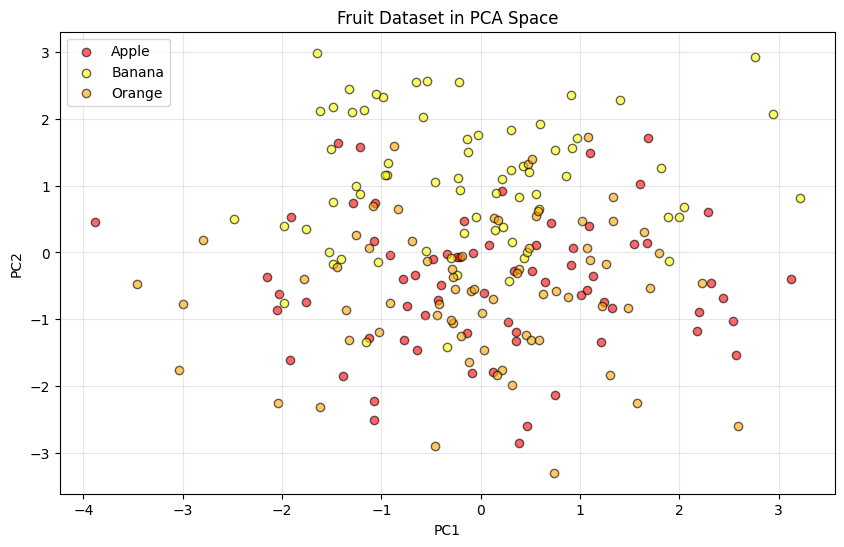

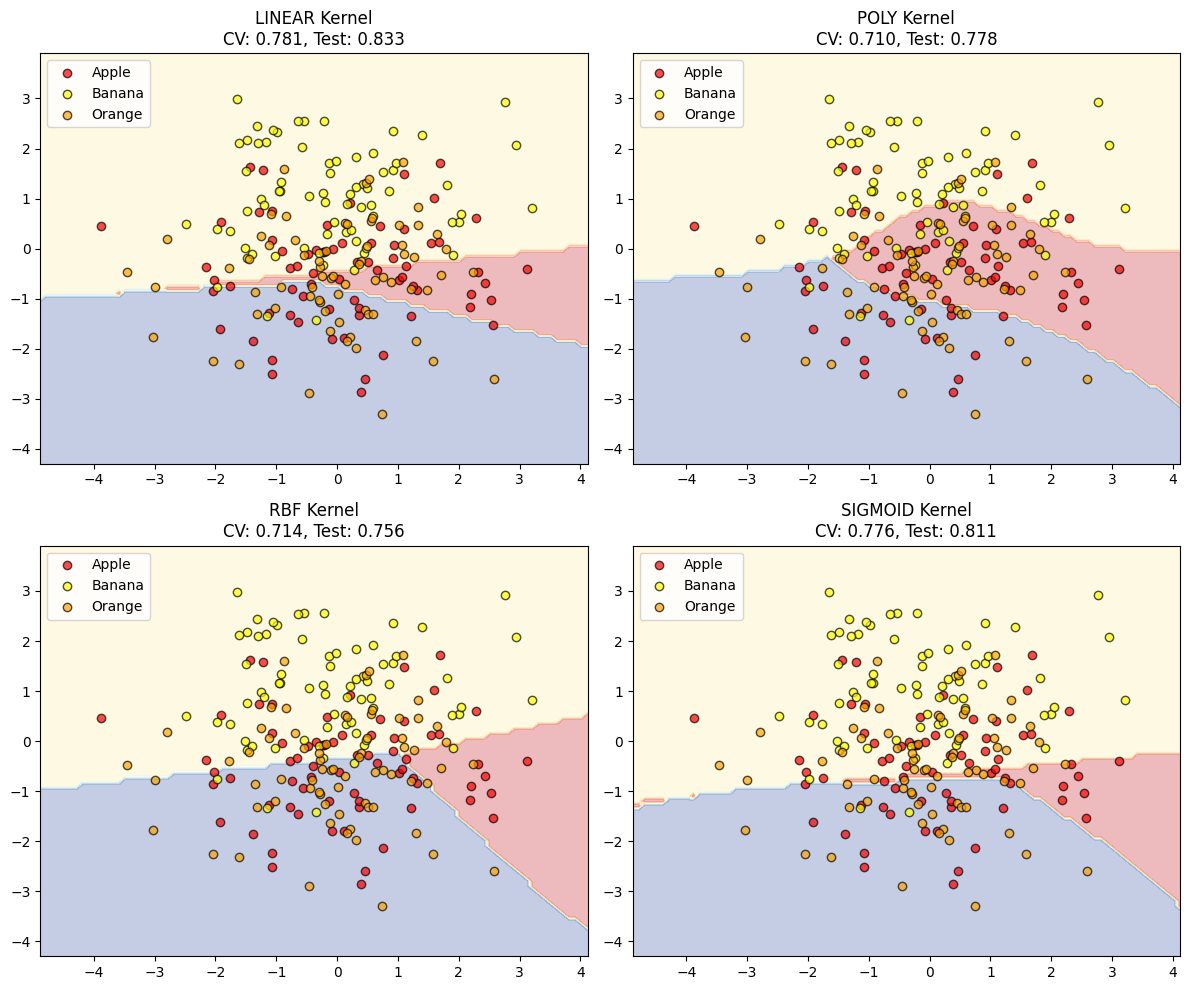


SVM KERNEL COMPARISON
----------------------------------------
Kernel    CV Acc    Test Acc  
linear    0.7810    0.8333    
poly      0.7095    0.7778    
rbf       0.7143    0.7556    
sigmoid   0.7762    0.8111    

Best Kernel: linear


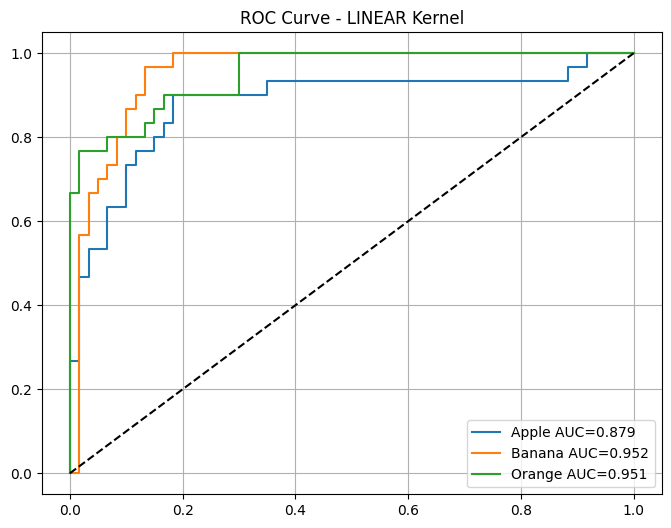

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split, cross_val_score

import warnings
warnings.filterwarnings('ignore')


# =========================
# LATIHAN 2: SVM FRUITS
# =========================
def praktikum_svm_fruits():
    print("\nLATIHAN 2: SVM DENGAN BERBAGAI KERNEL")
    print("=" * 50)

    # -------------------------
    # Dataset synthetic
    # -------------------------
    def create_fruit_dataset(n_samples=300):
        np.random.seed(42)
        n_features = 20

        # Apple
        apples = np.random.randn(n_samples, n_features)
        apples[:, 0] += 2
        apples[:, 1] += 1
        apples_labels = np.zeros(n_samples)

        # Banana
        bananas = np.random.randn(n_samples, n_features)
        bananas[:, 0] += 1
        bananas[:, 1] += 3
        bananas_labels = np.ones(n_samples)

        # Orange
        oranges = np.random.randn(n_samples, n_features)
        oranges[:, 0] += 1.5
        oranges[:, 1] += 1
        oranges[:, 2] += 2
        oranges_labels = np.ones(n_samples) * 2

        X = np.vstack([apples, bananas, oranges])
        y = np.hstack([apples_labels, bananas_labels, oranges_labels])

        return X, y

    X, y = create_fruit_dataset(100)
    fruit_names = ['Apple', 'Banana', 'Orange']

    print(f"Dataset Shape: {X.shape}")
    print(f"Class Distribution: {np.bincount(y.astype(int))}")

    # -------------------------
    # Split data
    # -------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # -------------------------
    # Scaling
    # -------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # -------------------------
    # PCA (2D for visualization)
    # -------------------------
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_train_scaled)

    # -------------------------
    # Visualisasi PCA
    # -------------------------
    plt.figure(figsize=(10, 6))
    colors = ['red', 'yellow', 'orange']

    for i, color in enumerate(colors):
        plt.scatter(
            X_pca[y_train == i, 0],
            X_pca[y_train == i, 1],
            c=color,
            label=fruit_names[i],
            alpha=0.6,
            edgecolors='black'
        )

    plt.title('Fruit Dataset in PCA Space')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # -------------------------
    # SVM kernels
    # -------------------------
    kernels = ['linear', 'poly', 'rbf', 'sigmoid']
    results = {}

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()

    for idx, kernel in enumerate(kernels):

        if kernel == 'poly':
            model = svm.SVC(kernel=kernel, degree=3, C=1.0, random_state=42)
        else:
            model = svm.SVC(kernel=kernel, C=1.0, random_state=42)

        # CV
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

        # Train
        model.fit(X_train_scaled, y_train)

        # Test accuracy
        acc = model.score(X_test_scaled, y_test)

        # -------------------------
        # Decision boundary FIX (PCA SPACE SAFE)
        # -------------------------
        x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
        y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

        xx, yy = np.meshgrid(
            np.arange(x_min, x_max, 0.1),
            np.arange(y_min, y_max, 0.1)
        )

        mesh = np.c_[xx.ravel(), yy.ravel()]

        # FIX: correct transformation pipeline
        Z = model.predict(
            scaler.inverse_transform(pca.inverse_transform(mesh))
        )
        Z = Z.reshape(xx.shape)

        axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)

        # scatter PCA points
        for i, color in enumerate(colors):
            axes[idx].scatter(
                X_pca[y_train == i, 0],
                X_pca[y_train == i, 1],
                c=color,
                label=fruit_names[i],
                edgecolors='black',
                alpha=0.7
            )

        axes[idx].set_title(
            f'{kernel.upper()} Kernel\nCV: {cv_scores.mean():.3f}, Test: {acc:.3f}'
        )
        axes[idx].legend()

        results[kernel] = {
            "cv": cv_scores.mean(),
            "test": acc,
            "model": model
        }

    plt.tight_layout()
    plt.show()

    # -------------------------
    # Compare results
    # -------------------------
    print("\nSVM KERNEL COMPARISON")
    print("-" * 40)
    print(f"{'Kernel':<10}{'CV Acc':<10}{'Test Acc':<10}")

    for k, v in results.items():
        print(f"{k:<10}{v['cv']:<10.4f}{v['test']:<10.4f}")

    # -------------------------
    # Best model
    # -------------------------
    best_kernel = max(results, key=lambda x: results[x]["test"])
    print("\nBest Kernel:", best_kernel)

    # -------------------------
    # ROC Curve
    # -------------------------
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

    best_model = OneVsRestClassifier(
        svm.SVC(kernel=best_kernel, probability=True, C=1.0, random_state=42)
    )

    best_model.fit(X_train_scaled, y_train)
    y_score = best_model.predict_proba(X_test_scaled)

    plt.figure(figsize=(8, 6))

    for i in range(len(fruit_names)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{fruit_names[i]} AUC={roc_auc:.3f}')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve - {best_kernel.upper()} Kernel')
    plt.legend()
    plt.grid()
    plt.show()

    return results, fruit_names


# =========================
# RUN
# =========================
svm_results, fruit_names = praktikum_svm_fruits()


PERBANDINGAN KNN vs SVM

Model           CV Acc     Test Acc   Precision  Recall     F1-Score  
----------------------------------------------------------------------
KNN (k=5)       0.9524     0.9111     0.9298     0.9111     0.9095    
SVM Linear      0.9714     0.9111     0.9155     0.9111     0.9107    
SVM RBF         0.9714     0.9333     0.9345     0.9333     0.9333    


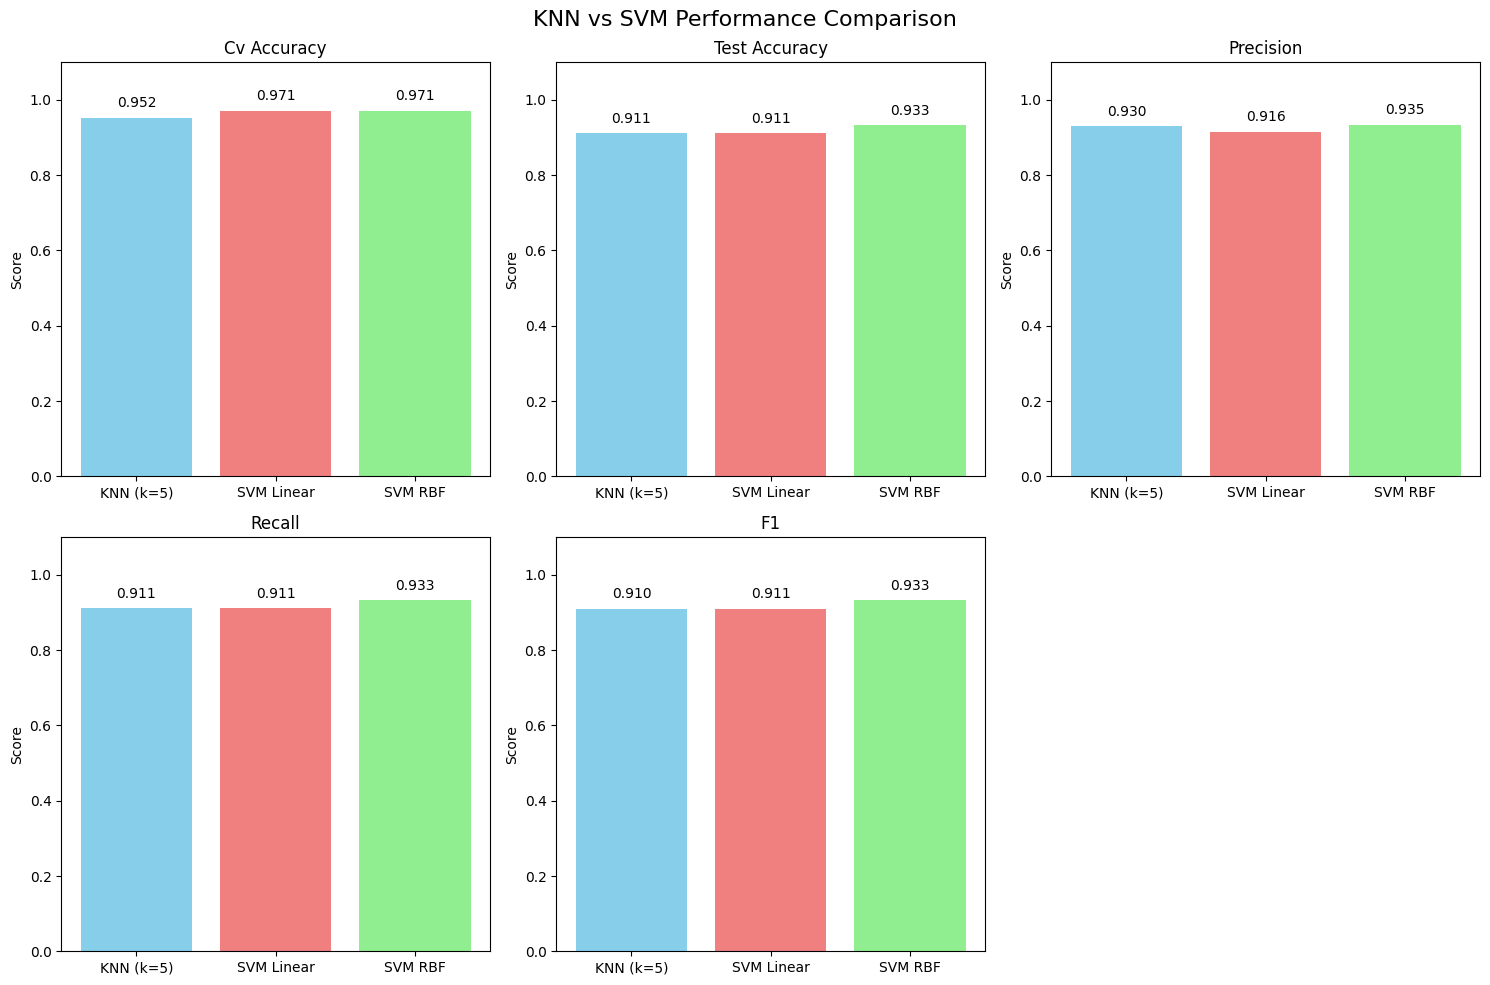

In [5]:
def compare_knn_svm():
    print("\nPERBANDINGAN KNN vs SVM")
    print("=" * 40)

    # Load iris dataset for comparison
    from sklearn.datasets import load_iris

    iris = load_iris()
    X = iris.data
    y = iris.target

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize models
    knn = KNeighborsClassifier(n_neighbors=5)
    svm_linear = svm.SVC(kernel='linear', C=1.0, random_state=42)
    svm_rbf = svm.SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

    models = {
        'KNN (k=5)': knn,
        'SVM Linear': svm_linear,
        'SVM RBF': svm_rbf
    }

    results = {}

    for name, model in models.items():
        # Cross-validation
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

        # Training and testing
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        # Calculate metrics
        from sklearn.metrics import precision_score, recall_score, f1_score

        accuracy = model.score(X_test_scaled, y_test)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        results[name] = {
            'cv_accuracy': cv_scores.mean(),
            'test_accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'model': model
        }

    # Display comparison
    print(f"\n{'Model':<15} {'CV Acc':<10} {'Test Acc':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
    print("-" * 70)
    for name, result in results.items():
        print(f"{name:<15} {result['cv_accuracy']:<10.4f} {result['test_accuracy']:<10.4f} "
              f"{result['precision']:<10.4f} {result['recall']:<10.4f} {result['f1']:<10.4f}")

    # Visual comparison
    metrics = ['CV Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score']
    model_names = list(models.keys())

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    for idx, metric in enumerate(['cv_accuracy', 'test_accuracy', 'precision', 'recall', 'f1']):
        values = [results[name][metric] for name in model_names]

        bars = axes[idx].bar(model_names, values, color=['skyblue', 'lightcoral', 'lightgreen'])
        axes[idx].set_title(metric.replace('_', ' ').title())
        axes[idx].set_ylabel('Score')
        axes[idx].set_ylim(0, 1.1)

        for bar, value in zip(bars, values):
            axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                          f'{value:.3f}', ha='center', va='bottom')

    # Hide empty subplot
    axes[-1].axis('off')

    plt.suptitle('KNN vs SVM Performance Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()

    return results

# Jalankan perbandingan
comparison_results = compare_knn_svm()